In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,MinMaxScaler,StandardScaler
from sklearn.metrics import accuracy_score ,confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import warnings
warnings.filterwarnings('ignore')

# Function

In [2]:
def Vsualize(column_name,data):
    
    values = data[column_name].value_counts().values.round(2)
    index = data[column_name].value_counts().index
    
    color = sns.color_palette('RdBu')
    plt.figure(figsize=(7,5))
    # pie chart of column
    plt.subplot(1, 2, 1)
    plt.title(f'Distribution of {column_name}')
    plt.pie(values, labels=index,autopct='%1.1f%%',colors=color)
   
    
    # Distribution of column
    plt.subplot(1, 2, 2)
    sns.countplot(x = column_name, data = data)
    plt.xticks(rotation = 45)
    plt.ylabel(f'Number of {column_name}')
    plt.savefig(f"my_graph.png")
    plt.tight_layout()
    plt.show()

In [3]:
def train_test_model(model,x_train,x_test,y_train,y_test):
    # Train model
    model.fit(x_train,y_train)
    # Acurracy of train data
    train_acc = accuracy_score(y_train,model.predict(x_train))
    print(f'\n Train accuracy_score = {train_acc * 100:.2f}% \n')

    # Test model
    y_predict = model.predict(x_test)
    test_acc = accuracy_score(y_test,y_predict)
    #Evaluate Model
    # Show accuracy_score and classification_report
    print(f'\n Test accuracy_score = {test_acc * 100:.2f}% \n')
    print(f'Test classification_report = \n {classification_report(y_test,y_predict)}')

In [4]:
path = '/kaggle/input/airline-passenger-satisfaction/train.csv'
data = pd.read_csv(path,index_col=0)



In [5]:
data.shape

(103904, 24)

In [6]:
data.sample(50)

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
12044,102432,Female,Loyal Customer,28,Personal Travel,Eco,223,4,4,4,...,4,3,4,4,3,4,4,0,0.0,neutral or dissatisfied
48721,91616,Female,Loyal Customer,59,Business travel,Business,1352,2,2,2,...,2,2,2,2,4,2,4,0,0.0,satisfied
56869,84082,Female,Loyal Customer,49,Personal Travel,Eco,773,2,4,2,...,5,5,2,5,3,5,3,0,0.0,neutral or dissatisfied
76906,86679,Male,Loyal Customer,49,Business travel,Business,1747,5,5,5,...,3,3,3,3,4,3,5,23,23.0,satisfied
60337,95598,Female,disloyal Customer,48,Business travel,Eco,670,1,1,1,...,2,4,1,2,2,3,2,8,10.0,neutral or dissatisfied
25212,1479,Male,Loyal Customer,49,Business travel,Business,3053,1,1,1,...,5,5,5,5,5,5,5,7,0.0,satisfied
68064,43415,Male,Loyal Customer,29,Business travel,Eco Plus,531,1,3,3,...,1,4,1,4,4,4,1,0,0.0,neutral or dissatisfied
72700,127624,Female,Loyal Customer,22,Business travel,Eco,1773,3,1,1,...,3,4,3,2,3,3,3,13,16.0,neutral or dissatisfied
11886,72070,Male,disloyal Customer,39,Business travel,Business,2486,1,1,1,...,4,3,3,4,5,4,4,0,0.0,neutral or dissatisfied
38143,108501,Female,disloyal Customer,21,Business travel,Eco,287,3,2,3,...,3,3,3,3,3,4,3,0,29.0,neutral or dissatisfied


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 103904 entries, 0 to 103903
Data columns (total 24 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   id                                 103904 non-null  int64  
 1   Gender                             103904 non-null  object 
 2   Customer Type                      103904 non-null  object 
 3   Age                                103904 non-null  int64  
 4   Type of Travel                     103904 non-null  object 
 5   Class                              103904 non-null  object 
 6   Flight Distance                    103904 non-null  int64  
 7   Inflight wifi service              103904 non-null  int64  
 8   Departure/Arrival time convenient  103904 non-null  int64  
 9   Ease of Online booking             103904 non-null  int64  
 10  Gate location                      103904 non-null  int64  
 11  Food and drink                     103904 no

In [8]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
id,103904.0,64924.210502,37463.812252,1.0,32533.75,64856.5,97368.25,129880.0
Age,103904.0,39.379706,15.114964,7.0,27.00,40.0,51.00,85.0
Flight Distance,103904.0,1189.448375,997.147281,31.0,414.00,843.0,1743.00,4983.0
Inflight wifi service,103904.0,2.729683,1.327829,0.0,2.00,3.0,4.00,5.0
Departure/Arrival time convenient,103904.0,3.060296,1.525075,0.0,2.00,3.0,4.00,5.0
Ease of Online booking,103904.0,2.756901,1.398929,0.0,2.00,3.0,4.00,5.0
Gate location,103904.0,2.976883,1.277621,0.0,2.00,3.0,4.00,5.0
Food and drink,103904.0,3.202129,1.329533,0.0,2.00,3.0,4.00,5.0
Online boarding,103904.0,3.250375,1.349509,0.0,2.00,3.0,4.00,5.0
Seat comfort,103904.0,3.439396,1.319088,0.0,2.00,4.0,5.00,5.0


In [9]:
data.isnull().sum()

id                                     0
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             310
satisfaction                           0
dtype: int64

In [10]:
data['Arrival Delay in Minutes'].value_counts()[100:200]

Arrival Delay in Minutes
100.0    69
99.0     68
90.0     65
93.0     65
94.0     63
         ..
181.0    13
213.0    13
187.0    13
189.0    13
200.0    12
Name: count, Length: 105, dtype: int64

<Axes: >

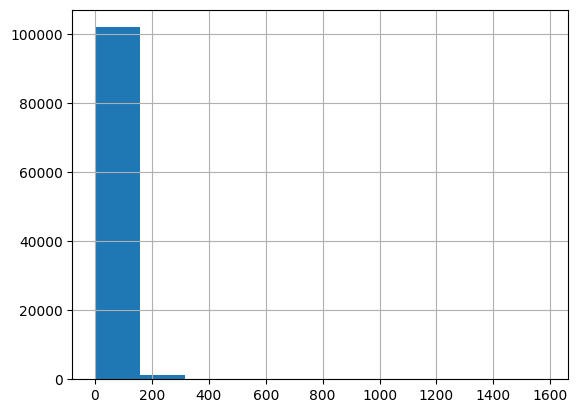

In [11]:
data['Arrival Delay in Minutes'].hist()

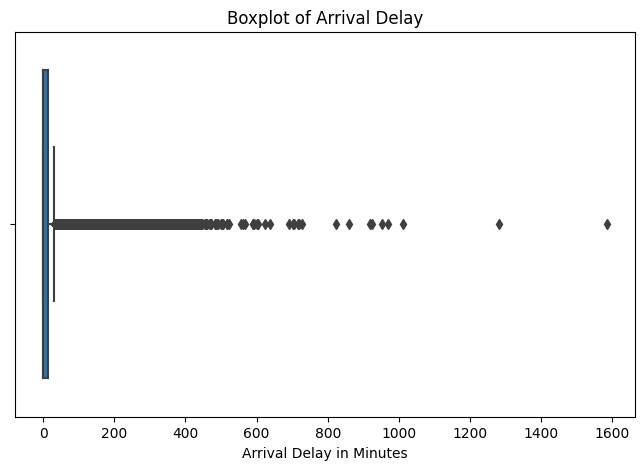

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(x=data['Arrival Delay in Minutes'])
plt.title("Boxplot of Arrival Delay")
plt.show()

In [13]:
data['Arrival Delay in Minutes'].mean()

15.178678301832152

In [14]:
median = data['Arrival Delay in Minutes'].median()
median

0.0

<Axes: >

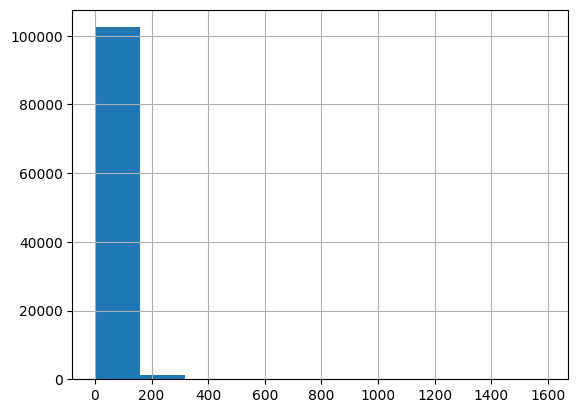

In [15]:
data['Departure Delay in Minutes'].hist()

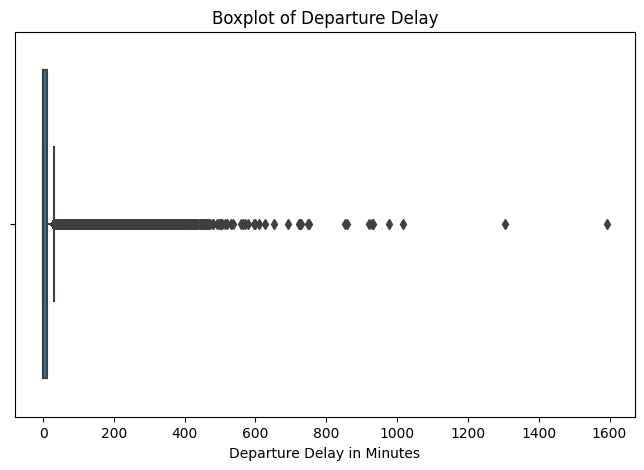

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(x=data['Departure Delay in Minutes'])
plt.title("Boxplot of Departure Delay")
plt.show()

In [17]:
object_data = data.select_dtypes(include = 'object')

In [18]:
object_data

,Gender,Customer Type,Type of Travel,Class,satisfaction
0,Male,Loyal Customer,Personal Travel,Eco Plus,neutral or dissatisfied
1,Male,disloyal Customer,Business travel,Business,neutral or dissatisfied
2,Female,Loyal Customer,Business travel,Business,satisfied
3,Female,Loyal Customer,Business travel,Business,neutral or dissatisfied
4,Male,Loyal Customer,Business travel,Business,satisfied
...,...,...,...,...,...
103899,Female,disloyal Customer,Business travel,Eco,neutral or dissatisfied
103900,Male,Loyal Customer,Business travel,Business,satisfied
103901,Male,disloyal Customer,Business travel,Business,neutral or dissatisfied
103902,Female,disloyal Customer,Business travel,Eco,neutral or dissatisfied


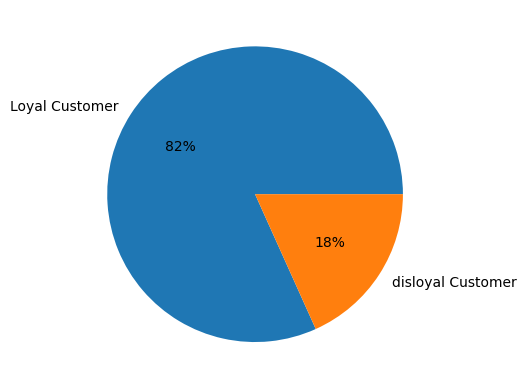

In [19]:
#	Gender	Customer Type	Type of Travel	Class	satisfaction
plt.pie(data['Customer Type'].value_counts(),labels =data['Customer Type'].value_counts().index,autopct='%1.0f%%')
plt.savefig("pie2.png")

Gender
Female    52727
Male      51177
Name: count, dtype: int64


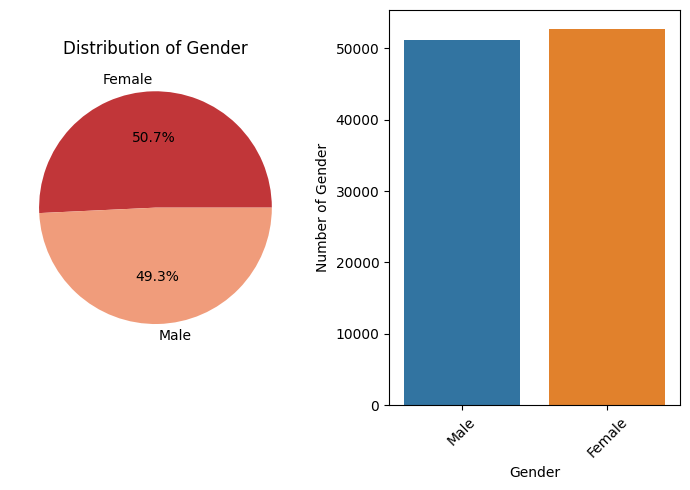

Customer Type
Loyal Customer       84923
disloyal Customer    18981
Name: count, dtype: int64


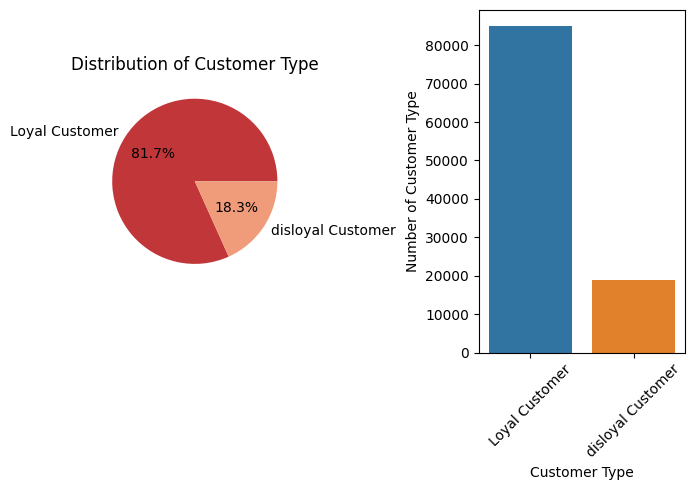

Type of Travel
Business travel    71655
Personal Travel    32249
Name: count, dtype: int64


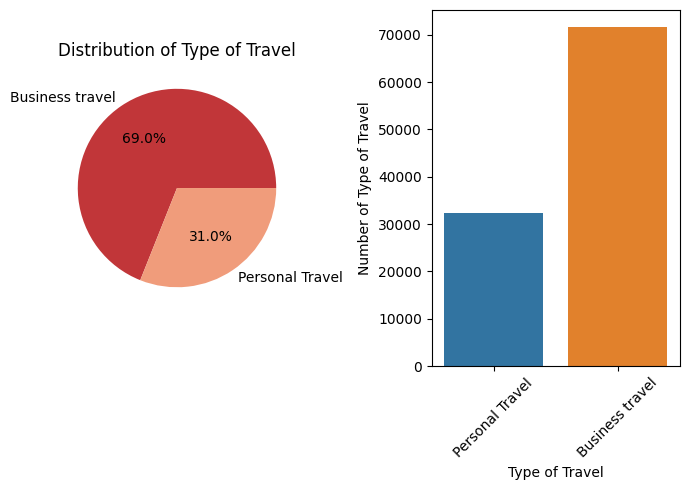

Class
Business    49665
Eco         46745
Eco Plus     7494
Name: count, dtype: int64


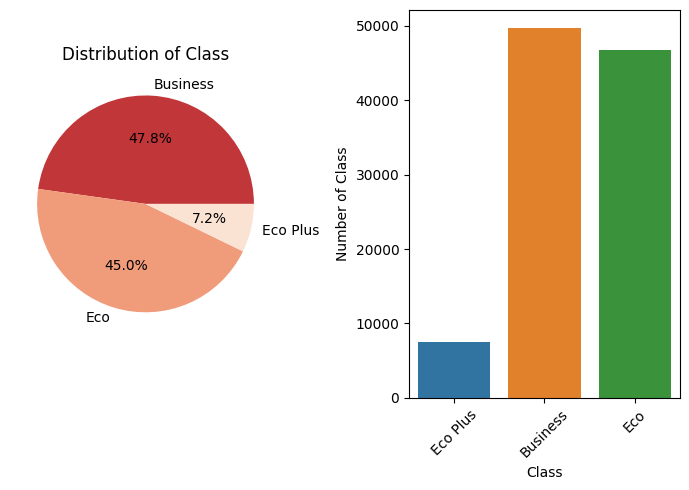

satisfaction
neutral or dissatisfied    58879
satisfied                  45025
Name: count, dtype: int64


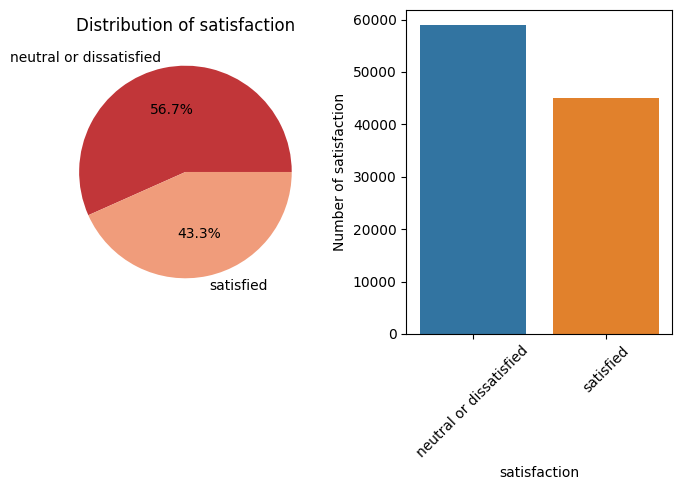

In [20]:
for column in object_data.columns:
    print(data[column].value_counts())
    Vsualize(column,data)
    

In [21]:
object_data.columns

Index(['Gender', 'Customer Type', 'Type of Travel', 'Class', 'satisfaction'], dtype='object')

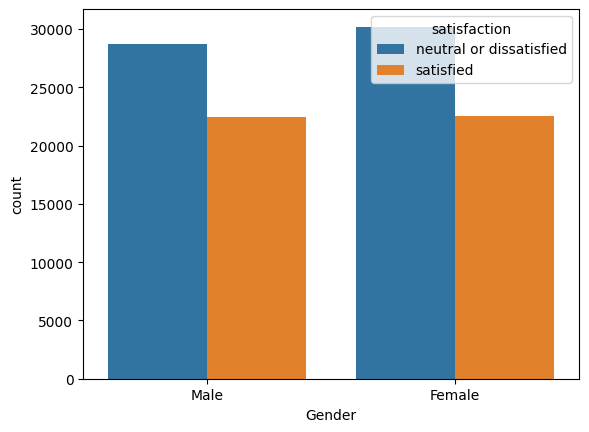

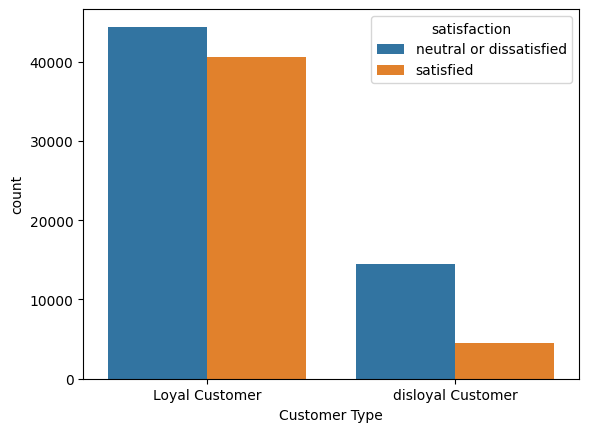

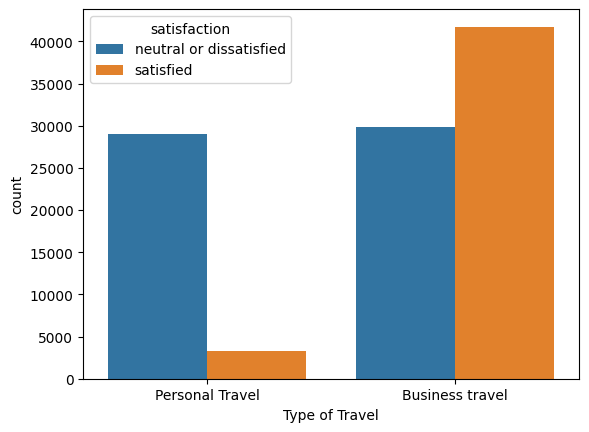

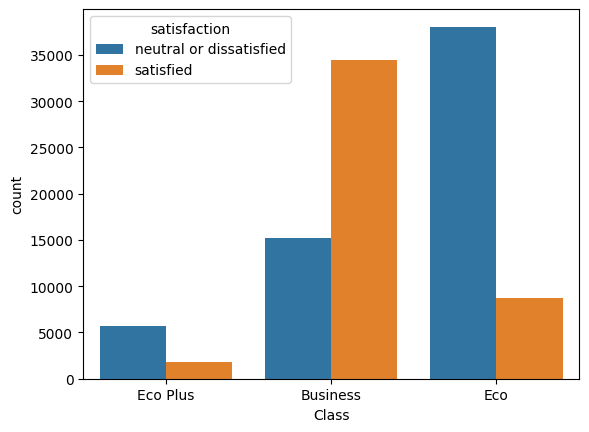

In [22]:
for column in object_data.columns[:-1]:
    sns.countplot(x=column,data=data,hue = 'satisfaction')
    plt.show()
    

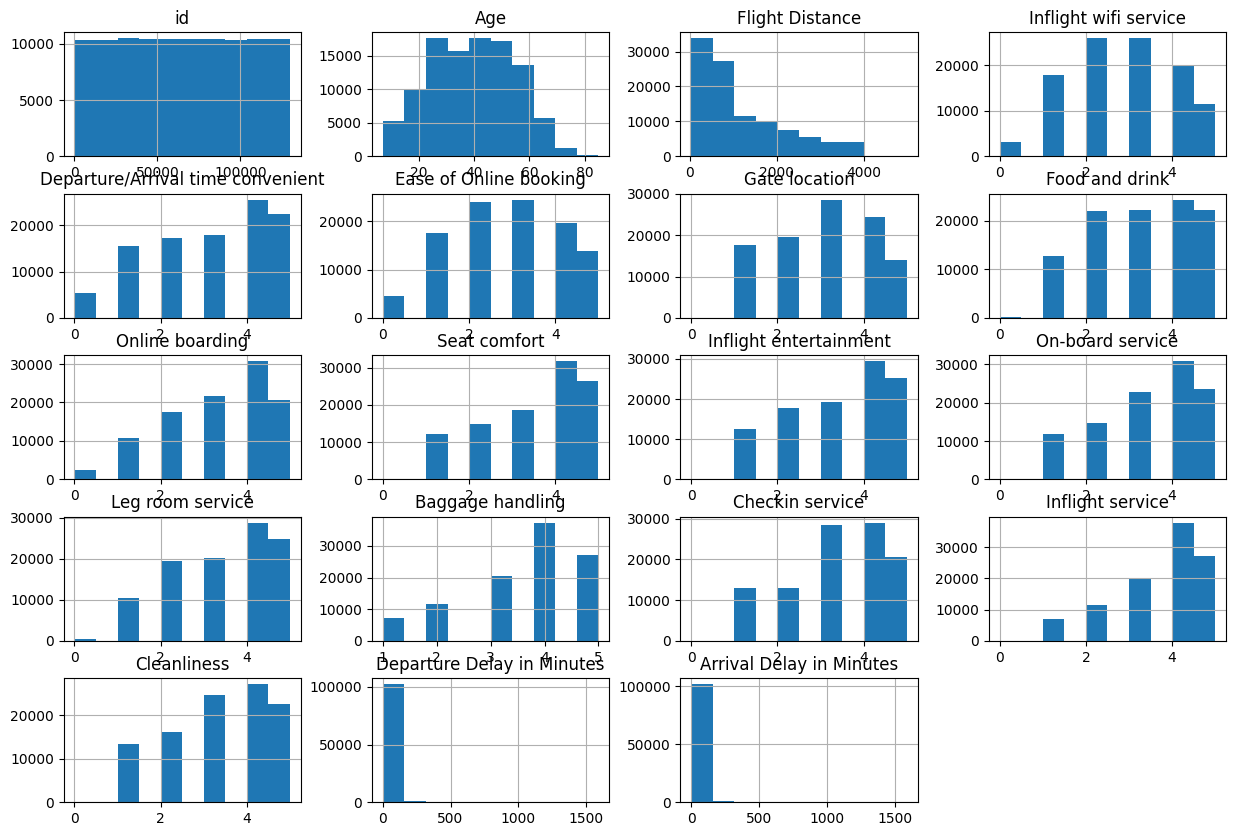

In [23]:
data.hist(figsize=(15,10))
plt.show()

In [24]:
for column in object_data.columns:
    le=LabelEncoder()
    data[column] = le.fit_transform(data[column])
    print(le.classes_)

['Female' 'Male']
['Loyal Customer' 'disloyal Customer']
['Business travel' 'Personal Travel']
['Business' 'Eco' 'Eco Plus']
['neutral or dissatisfied' 'satisfied']


In [25]:
data.columns

Index(['id', 'Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class',
       'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       'satisfaction'],
      dtype='object')

In [26]:

data['Service'] = data['Inflight wifi service']\
       +data['Departure/Arrival time convenient']+ data['Ease of Online booking']\
       +data['Gate location']+data['Food and drink']+data['Online boarding'] + data['Seat comfort']\
       +data['Inflight entertainment']+data['On-board service']+data['Leg room service']\
       +data['Baggage handling'] + data['Checkin service']+data['Inflight service']\
       +data['Cleanliness']

In [27]:
data['Service'].value_counts()

Service
45    4254
44    4180
47    4179
49    4149
46    4146
43    4091
48    4084
50    3863
42    3744
51    3729
41    3605
40    3574
52    3441
39    3403
53    3286
38    3093
54    3087
37    2860
55    2774
36    2714
35    2619
56    2427
34    2363
57    2248
33    2064
58    2051
32    1803
59    1742
31    1588
60    1547
61    1335
30    1281
29    1127
62    1123
28     898
63     829
27     691
64     666
26     560
65     503
25     423
66     370
24     353
67     240
23     225
22     175
68     132
21      81
20      70
69      42
19      31
18      15
17      13
70       7
16       4
15       2
Name: count, dtype: int64

<Axes: >

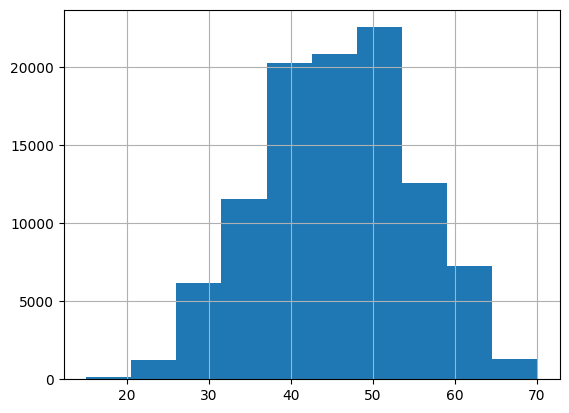

In [28]:
data['Service'].hist()

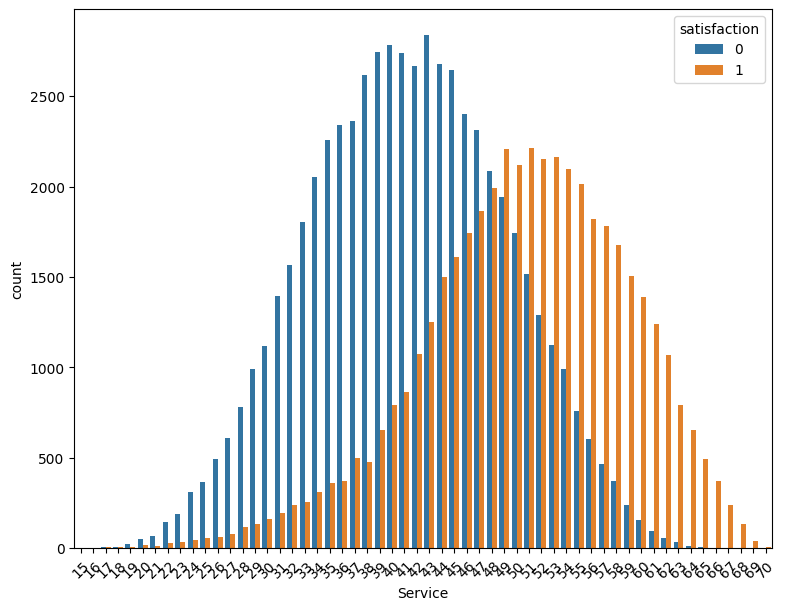

In [29]:
plt.figure(figsize=(9,7))
sns.countplot(x= 'Service',data=data,hue='satisfaction')
plt.xticks(rotation=45)
plt.show()

In [30]:

data.drop(['id','Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness'],axis=1,inplace=True)

In [31]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 103904 entries, 0 to 103903
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Gender                      103904 non-null  int64  
 1   Customer Type               103904 non-null  int64  
 2   Age                         103904 non-null  int64  
 3   Type of Travel              103904 non-null  int64  
 4   Class                       103904 non-null  int64  
 5   Flight Distance             103904 non-null  int64  
 6   Departure Delay in Minutes  103904 non-null  int64  
 7   Arrival Delay in Minutes    103594 non-null  float64
 8   satisfaction                103904 non-null  int64  
 9   Service                     103904 non-null  int64  
dtypes: float64(1), int64(9)
memory usage: 8.7 MB


## Feature Engineering 

In [32]:
corelation = data.corr()
corelation

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction,Service
Gender,1.000000,-0.031732,0.008928,0.006909,-0.012870,0.005828,0.002935,0.000396,0.012211,0.013445
Customer Type,-0.031732,1.000000,-0.281674,-0.308333,0.042638,-0.225200,0.004036,0.004747,-0.187638,-0.136725
Age,0.008928,-0.281674,1.000000,-0.048524,-0.117370,0.099461,-0.010152,-0.012147,0.137167,0.093829
Type of Travel,0.006909,-0.308333,-0.048524,1.000000,0.487088,-0.267344,-0.005432,-0.005683,-0.449000,-0.120930
Class,-0.012870,0.042638,-0.117370,0.487088,1.000000,-0.427219,0.010281,0.014701,-0.449321,-0.250598
Flight Distance,0.005828,-0.225200,0.099461,-0.267344,-0.427219,1.000000,0.002158,-0.002426,0.298780,0.161468
Departure Delay in Minutes,0.002935,0.004036,-0.010152,-0.005432,0.010281,0.002158,1.000000,0.965481,-0.050494,-0.032053
Arrival Delay in Minutes,0.000396,0.004747,-0.012147,-0.005683,0.014701,-0.002426,0.965481,1.000000,-0.057582,-0.036744
satisfaction,0.012211,-0.187638,0.137167,-0.449000,-0.449321,0.298780,-0.050494,-0.057582,1.000000,0.496138
Service,0.013445,-0.136725,0.093829,-0.120930,-0.250598,0.161468,-0.032053,-0.036744,0.496138,1.000000


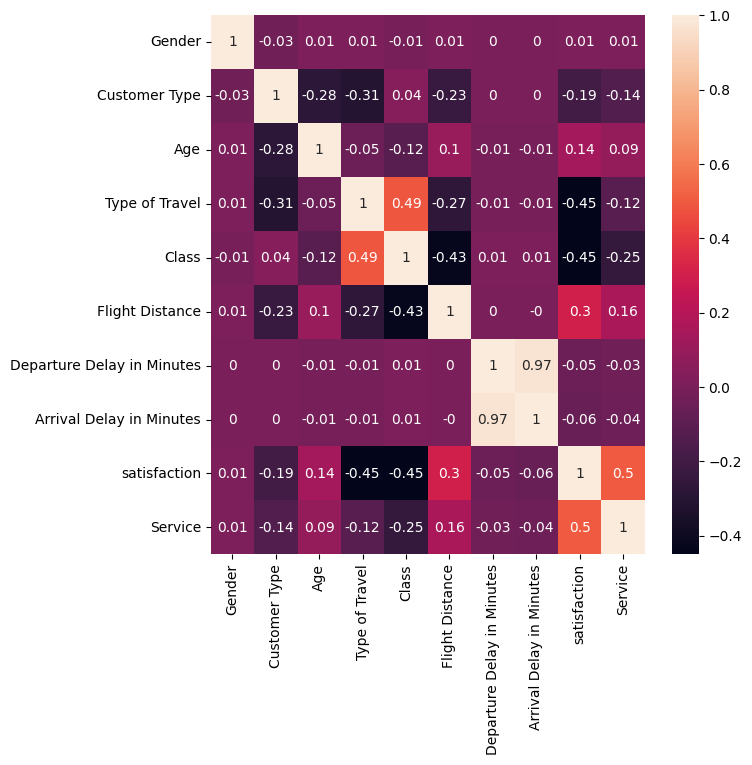

In [33]:
plt.figure(figsize=(7,7))
sns.heatmap(corelation.round(2),annot = True)
plt.show()

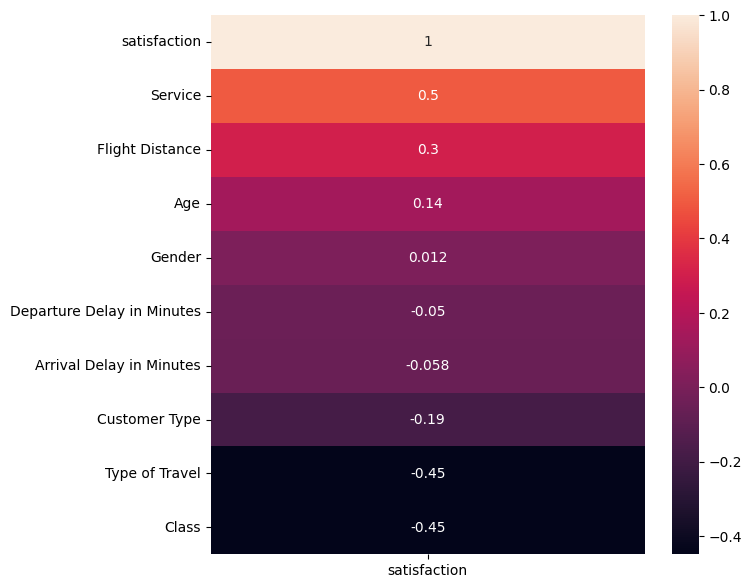

In [34]:
plt.figure(figsize=(7,7))
sns.heatmap(corelation[['satisfaction']].sort_values('satisfaction',ascending = False),annot = True)
plt.show()

In [35]:
# not importand and have null value
data.drop('Arrival Delay in Minutes',axis=1,inplace=True)

In [36]:
x_train = data.drop('satisfaction',axis=1)
y_train = data['satisfaction']

In [37]:
scaler = MinMaxScaler()
x_train_scaled = scaler.fit_transform(x_train)


## Test data

In [38]:
path = '/kaggle/input/airline-passenger-satisfaction/test.csv'
test_data = pd.read_csv(path,index_col=0)

In [39]:
test_data.shape

(25976, 24)

In [40]:
test_data.isnull().sum()

id                                    0
Gender                                0
Customer Type                         0
Age                                   0
Type of Travel                        0
Class                                 0
Flight Distance                       0
Inflight wifi service                 0
Departure/Arrival time convenient     0
Ease of Online booking                0
Gate location                         0
Food and drink                        0
Online boarding                       0
Seat comfort                          0
Inflight entertainment                0
On-board service                      0
Leg room service                      0
Baggage handling                      0
Checkin service                       0
Inflight service                      0
Cleanliness                           0
Departure Delay in Minutes            0
Arrival Delay in Minutes             83
satisfaction                          0
dtype: int64

In [41]:
xobject_data = test_data.select_dtypes(include = 'object')
for column in xobject_data.columns:
    le=LabelEncoder()
    test_data[column] = le.fit_transform(test_data[column])
    
test_data['Service'] = test_data['Inflight wifi service']\
       +test_data['Departure/Arrival time convenient']+ test_data['Ease of Online booking']\
       +test_data['Gate location']+test_data['Food and drink']+test_data['Online boarding'] + test_data['Seat comfort']\
       +test_data['Inflight entertainment']+test_data['On-board service']+test_data['Leg room service']\
       +test_data['Baggage handling'] + test_data['Checkin service']+test_data['Inflight service']\
       +test_data['Cleanliness']
test_data.drop(['id','Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service','Arrival Delay in Minutes',
       'Cleanliness'],axis=1,inplace=True)

In [42]:
x_test = test_data.drop('satisfaction',axis=1)
y_test = test_data['satisfaction']

In [43]:
# just transform not fit transform because not seen test data
x_test_scaled = scaler.transform(x_test) 

# ML Models

In [44]:
model = GaussianNB()
train_test_model(model,x_train_scaled,x_test_scaled,y_train,y_test)


 Train accuracy_score = 81.43% 


 Test accuracy_score = 80.74% 

Test classification_report = 
               precision    recall  f1-score   support

           0       0.82      0.84      0.83     14573
           1       0.79      0.77      0.78     11403

    accuracy                           0.81     25976
   macro avg       0.80      0.80      0.80     25976
weighted avg       0.81      0.81      0.81     25976



In [45]:
model = LogisticRegression()
train_test_model(model,x_train_scaled,x_test_scaled,y_train,y_test)


 Train accuracy_score = 84.42% 


 Test accuracy_score = 83.68% 

Test classification_report = 
               precision    recall  f1-score   support

           0       0.85      0.86      0.86     14573
           1       0.82      0.80      0.81     11403

    accuracy                           0.84     25976
   macro avg       0.83      0.83      0.83     25976
weighted avg       0.84      0.84      0.84     25976



# DL Models

In [46]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

2025-10-13 08:31:26.352916: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760344286.548424      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760344286.599547      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## Model 1

### Early stop

In [47]:
from tensorflow.keras.callbacks import EarlyStopping
# check validition loss and stop if not change for 10 epoch
early_stop = EarlyStopping(monitor='val_loss',  patience=10,restore_best_weights=True) 

In [48]:
def Model1():
    model =keras.Sequential([
    layers.Dense(300, activation='relu'),
    layers.Dense(500,activation='relu'),
    layers.Dense(600,activation='relu'),
    layers.Dense(400,activation='relu'),
    layers.Dense(100,activation='relu'),
    layers.Dense(1, activation='sigmoid')
    ])
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01)
    model.compile(optimizer=optimizer,loss='binary_crossentropy',metrics =['binary_accuracy'])
    return model

In [49]:
model = Model1()
history = model.fit(x_train, y_train, epochs=100,batch_size=16, validation_split=0.2)

I0000 00:00:1760344297.919957      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1760344297.920620      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/100


I0000 00:00:1760344300.887195      67 service.cc:148] XLA service 0x7b8c98023af0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1760344300.887677      67 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1760344300.887700      67 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1760344301.309084      67 cuda_dnn.cc:529] Loaded cuDNN version 90300


  73/5196 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - binary_accuracy: 0.5108 - loss: 256.5841

I0000 00:00:1760344302.742306      67 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


5196/5196 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - binary_accuracy: 0.5877 - loss: 8.2655 - val_binary_accuracy: 0.5707 - val_loss: 0.6840
Epoch 2/100
5196/5196 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - binary_accuracy: 0.5680 - loss: 0.6844 - val_binary_accuracy: 0.5707 - val_loss: 0.6831
Epoch 3/100
5196/5196 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - binary_accuracy: 0.5689 - loss: 0.6838 - val_binary_accuracy: 0.5707 - val_loss: 0.6831
Epoch 4/100
5196/5196 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - binary_accuracy: 0.5666 - loss: 0.6845 - val_binary_accuracy: 0.5707 - val_loss: 0.6870
Epoch 5/100
5196/5196 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - binary_accuracy: 0.5668 - loss: 0.6847 - val_binary_accuracy: 0.5707 - val_loss: 0.6833
Epoch 6/100
5196/5196 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - binary_accuracy: 0.5651 - loss: 0.6851 - val_binary_accuracy: 0.5707 - val_loss: 0.6832
Epoch 7/100
5196/5196 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - binary_accuracy: 0.5658 - loss: 0.6848 - val_binary_accuracy: 0.5707 - val_los

In [50]:
result = pd.DataFrame(history.history)

In [51]:
result.sample(7)

,binary_accuracy,loss,val_binary_accuracy,val_loss
15,0.565656,0.684874,0.570714,0.683182
92,0.565656,0.684883,0.570714,0.683194
0,0.574522,1.622298,0.570666,0.683997
75,0.565656,0.684816,0.570714,0.684342
71,0.565656,0.684841,0.570714,0.683137
6,0.565656,0.684842,0.570714,0.683652
96,0.565656,0.684736,0.570714,0.683119


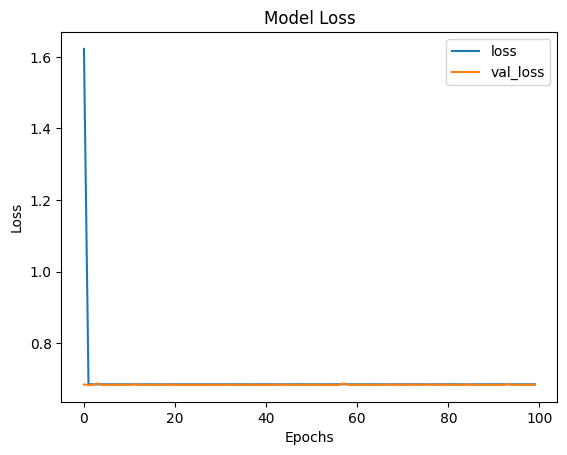

In [52]:
result[['loss','val_loss']].plot()
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

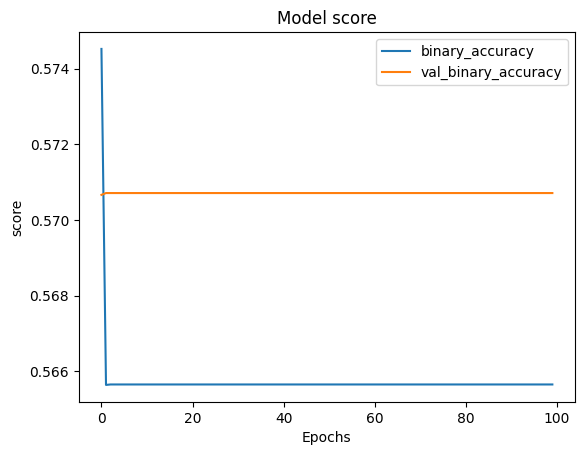

In [53]:
result[['binary_accuracy','val_binary_accuracy']].plot()
plt.title('Model score')
plt.xlabel('Epochs')
plt.ylabel('score')
plt.show()

## Model 2

In [54]:
def Model2():
    model =keras.Sequential([
    layers.Dense(100, activation='relu'),
    layers.Dense(200,activation='tanh'),
    layers.Dense(70,activation='tanh'),
    layers.Dense(1, activation='sigmoid')
    ])
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001)
    model.compile(optimizer=optimizer,loss='binary_crossentropy',metrics =['binary_accuracy'])
    return model

In [55]:
model = Model2()
history = model.fit(x_train, y_train, epochs=100,batch_size=16, validation_split=0.2, callbacks =[early_stop])

Epoch 1/100
5196/5196 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - binary_accuracy: 0.5550 - loss: 0.6937 - val_binary_accuracy: 0.4293 - val_loss: 0.7106
Epoch 2/100
5196/5196 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - binary_accuracy: 0.5593 - loss: 0.6875 - val_binary_accuracy: 0.5707 - val_loss: 0.6861
Epoch 3/100
5196/5196 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - binary_accuracy: 0.5596 - loss: 0.6874 - val_binary_accuracy: 0.5707 - val_loss: 0.6832
Epoch 4/100
5196/5196 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - binary_accuracy: 0.5625 - loss: 0.6868 - val_binary_accuracy: 0.5707 - val_loss: 0.6833
Epoch 5/100
5196/5196 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - binary_accuracy: 0.5619 - loss: 0.6867 - val_binary_accuracy: 0.5707 - val_loss: 0.6831
Epoch 6/100
5196/5196 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - binary_accuracy: 0.5630 - loss: 0.6868 - val_binary_accuracy: 0.5707 - val_loss: 0.6847
Epoch 7/100
5196/5196 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - binary_accuracy: 0.5631 - loss: 0.6866 - val_binary_accuracy: 0.57

In [56]:
result = pd.DataFrame(history.history)

In [57]:
result.sample(7)

,binary_accuracy,loss,val_binary_accuracy,val_loss
4,0.562528,0.686678,0.570714,0.683134
1,0.563105,0.686700,0.570714,0.686075
8,0.563394,0.686669,0.570714,0.684607
0,0.560771,0.687901,0.429286,0.710572
13,0.563322,0.686521,0.570714,0.694774
11,0.563250,0.686760,0.570714,0.685256
3,0.562696,0.686605,0.570714,0.683330


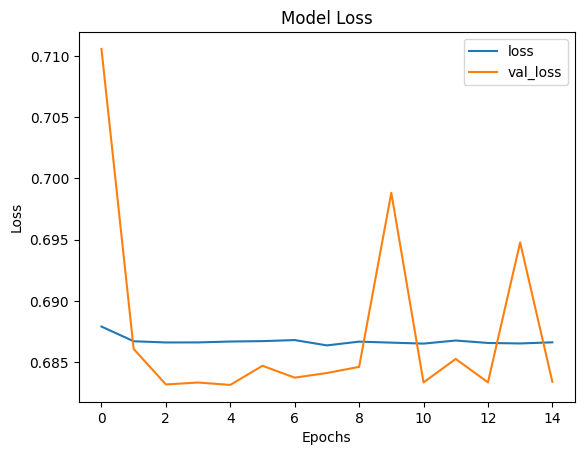

In [58]:
result[['loss','val_loss']].plot()
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()


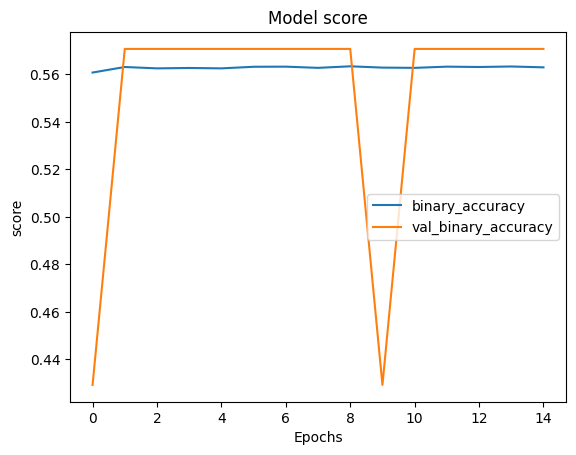

In [59]:
result[['binary_accuracy','val_binary_accuracy']].plot()
plt.title('Model score')
plt.xlabel('Epochs')
plt.ylabel('score')
plt.show()

## Model 3

In [60]:
def Model3():
    model =keras.Sequential([
    layers.Dense(100),
    layers.LeakyReLU(),
    layers.Dense(200),
    layers.LeakyReLU(),
    layers.Dense(70,activation='tanh'),
    layers.Dense(1, activation='sigmoid')
    ])
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.03)
    model.compile(optimizer=optimizer,loss='binary_crossentropy',metrics =['binary_accuracy'])
    return model

In [61]:
model = Model3()
history = model.fit(x_train, y_train, epochs=100,batch_size=32, validation_split=0.2, callbacks =[early_stop])

Epoch 1/100
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - binary_accuracy: 0.5525 - loss: 0.6913 - val_binary_accuracy: 0.5707 - val_loss: 0.6868
Epoch 2/100
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - binary_accuracy: 0.5538 - loss: 0.6887 - val_binary_accuracy: 0.5708 - val_loss: 0.6873
Epoch 3/100
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - binary_accuracy: 0.5510 - loss: 0.6904 - val_binary_accuracy: 0.5707 - val_loss: 0.6853
Epoch 4/100
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - binary_accuracy: 0.5513 - loss: 0.6909 - val_binary_accuracy: 0.5707 - val_loss: 0.6843
Epoch 5/100
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - binary_accuracy: 0.5512 - loss: 0.6901 - val_binary_accuracy: 0.5707 - val_loss: 0.6832
Epoch 6/100
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - binary_accuracy: 0.5491 - loss: 0.6904 - val_binary_accuracy: 0.5707 - val_loss: 0.6871
Epoch 7/100
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - binary_accuracy: 0.5520 - loss: 0.6901 - val_binary_accuracy: 0.5707 - va

In [62]:
result = pd.DataFrame(history.history)

In [63]:
result.sample(7)

,binary_accuracy,loss,val_binary_accuracy,val_loss
14,0.551027,0.689761,0.570762,0.685439
6,0.550112,0.690225,0.570714,0.688935
1,0.551809,0.689398,0.570762,0.687271
5,0.551207,0.690079,0.570714,0.687097
9,0.552230,0.690488,0.570714,0.685228
8,0.551688,0.689910,0.570714,0.689337
3,0.551291,0.690486,0.570714,0.684264


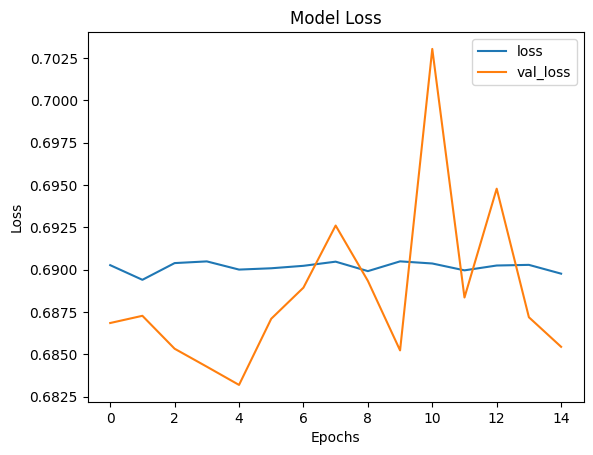

In [64]:
result[['loss','val_loss']].plot()
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

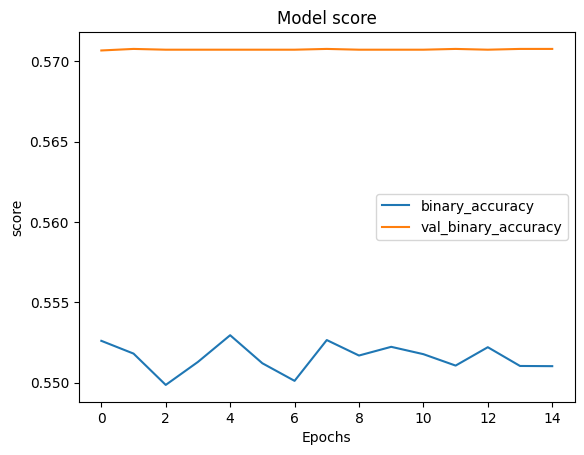

In [65]:
result[['binary_accuracy','val_binary_accuracy']].plot()
plt.title('Model score')
plt.xlabel('Epochs')
plt.ylabel('score')
plt.show()

In [66]:
from sklearn.metrics import confusion_matrix
ypred=model.predict(x_test)
ypred=(ypred>0.5)
cm=confusion_matrix(y_test,ypred)

812/812 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


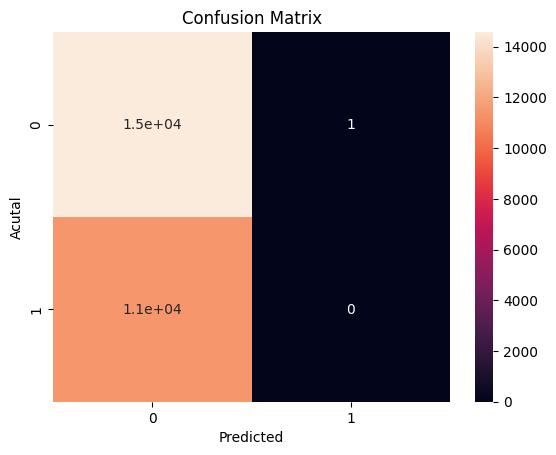

In [67]:
sns.heatmap(cm,annot=True)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Acutal')
plt.show()

## Model 4

In [68]:
def Model4():
        model =keras.Sequential([
        layers.Dense(70, activation='tanh'),
        layers.BatchNormalization(), # to normalize layer
        layers.Dense(120,activation='tanh'),
        layers.BatchNormalization(),
        layers.Dense(40,activation='tanh'),
        layers.BatchNormalization(),
        layers.Dense(1, activation='sigmoid')
        ])
        optimizer=tf.keras.optimizers.Lion(learning_rate=0.001)
        model.compile(optimizer=optimizer,loss='binary_crossentropy',metrics =['binary_accuracy'])
        return model

In [69]:
model = Model4()
history = model.fit(x_train, y_train, epochs=100,batch_size=64, validation_split=0.2, callbacks =[early_stop])

Epoch 1/100
1299/1299 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - binary_accuracy: 0.5630 - loss: 0.6906 - val_binary_accuracy: 0.5707 - val_loss: 0.8059
Epoch 2/100
1299/1299 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - binary_accuracy: 0.5669 - loss: 0.6845 - val_binary_accuracy: 0.5707 - val_loss: 1.1896
Epoch 3/100
1299/1299 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - binary_accuracy: 0.5659 - loss: 0.6846 - val_binary_accuracy: 0.5707 - val_loss: 0.6841
Epoch 4/100
1299/1299 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - binary_accuracy: 0.5657 - loss: 0.6847 - val_binary_accuracy: 0.5707 - val_loss: 0.6835
Epoch 5/100
1299/1299 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - binary_accuracy: 0.5674 - loss: 0.6842 - val_binary_accuracy: 0.5707 - val_loss: 0.6832
Epoch 6/100
1299/1299 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - binary_accuracy: 0.5647 - loss: 0.6849 - val_binary_accuracy: 0.5707 - val_loss: 0.6820
Epoch 7/100
1299/1299 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - binary_accuracy: 0.5651 - loss: 0.6853 - val_binary_accuracy: 0.4344 - va

In [70]:
result = pd.DataFrame(history.history)

In [71]:
result.sample(7)

,binary_accuracy,loss,val_binary_accuracy,val_loss
14,0.565656,0.684720,0.570714,0.683485
15,0.565656,0.684697,0.570714,0.688970
1,0.565644,0.684917,0.570714,1.189632
12,0.565656,0.684690,0.570714,0.683176
10,0.565451,0.686410,0.570714,0.806575
8,0.565584,0.685016,0.568211,0.836166
9,0.563887,0.690614,0.568693,0.996727


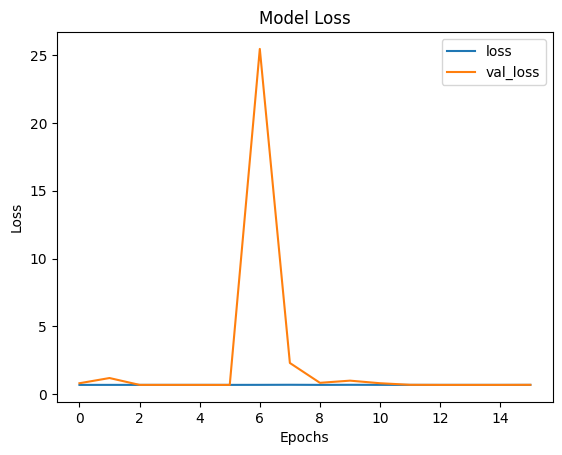

In [72]:
result[['loss','val_loss']].plot()
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()


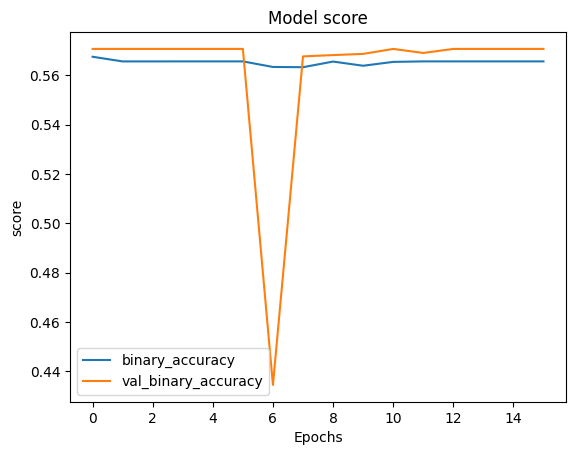

In [73]:
result[['binary_accuracy','val_binary_accuracy']].plot()
plt.title('Model score')
plt.xlabel('Epochs')
plt.ylabel('score')
plt.show()

In [74]:
from sklearn.metrics import confusion_matrix
ypred=model.predict(x_test)
ypred=(ypred>0.5)
cm=confusion_matrix(y_test,ypred)

812/812 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


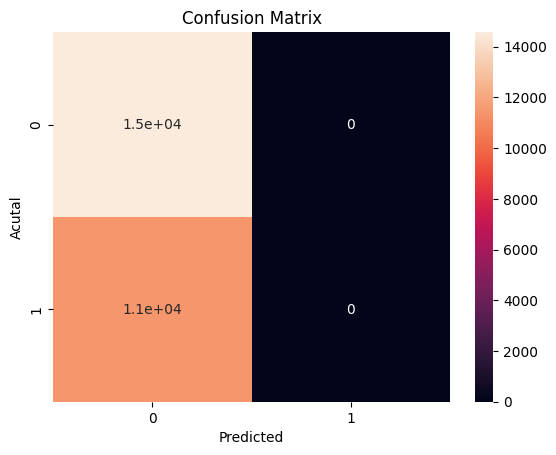

In [75]:
sns.heatmap(cm,annot=True)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Acutal')
plt.show()

## Model 5

In [76]:
def Model5():
    model =keras.Sequential([
    layers.Dense(70, activation='tanh'),
    layers.Dense(150,activation='tanh'),
    layers.Dense(240,activation='tanh'),
    layers.Dense(110,activation='tanh'),
    layers.Dense(50,activation='tanh'),
    layers.Dense(1, activation='sigmoid')
    ])
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001)
    model.compile(optimizer=optimizer,loss='binary_crossentropy',metrics =['binary_accuracy'])
    return model

In [77]:
model = Model5()
history = model.fit(x_train, y_train, epochs=300,batch_size=64, validation_split=0.2)

Epoch 1/300
1299/1299 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - binary_accuracy: 0.6151 - loss: 0.6560 - val_binary_accuracy: 0.6650 - val_loss: 0.6133
Epoch 2/300
1299/1299 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - binary_accuracy: 0.6586 - loss: 0.6184 - val_binary_accuracy: 0.7011 - val_loss: 0.5792
Epoch 3/300
1299/1299 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - binary_accuracy: 0.7012 - loss: 0.5774 - val_binary_accuracy: 0.7618 - val_loss: 0.5196
Epoch 4/300
1299/1299 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - binary_accuracy: 0.7618 - loss: 0.5055 - val_binary_accuracy: 0.7945 - val_loss: 0.4597
Epoch 5/300
1299/1299 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - binary_accuracy: 0.7873 - loss: 0.4710 - val_binary_accuracy: 0.8143 - val_loss: 0.4278
Epoch 6/300
1299/1299 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - binary_accuracy: 0.8033 - loss: 0.4437 - val_binary_accuracy: 0.8251 - val_loss: 0.4109
Epoch 7/300
1299/1299 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - binary_accuracy: 0.8151 - loss: 0.4248 - val_binary_accuracy: 0.8289 - va

In [78]:
result = pd.DataFrame(history.history)

In [79]:
result.sample(7)

,binary_accuracy,loss,val_binary_accuracy,val_loss
56,0.852375,0.358079,0.849622,0.367412
141,0.855239,0.347577,0.862615,0.340047
9,0.832513,0.396523,0.833165,0.387176
63,0.851762,0.356853,0.862037,0.340468
77,0.851269,0.355733,0.863192,0.342817
215,0.857957,0.341415,0.861797,0.343109
4,0.791021,0.464144,0.814350,0.427769


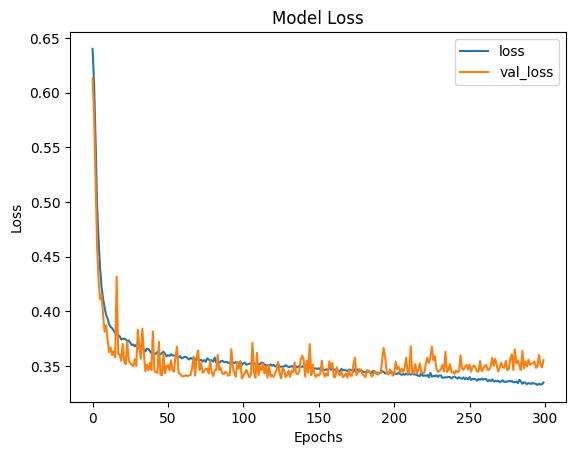

In [80]:
result[['loss','val_loss']].plot()
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()



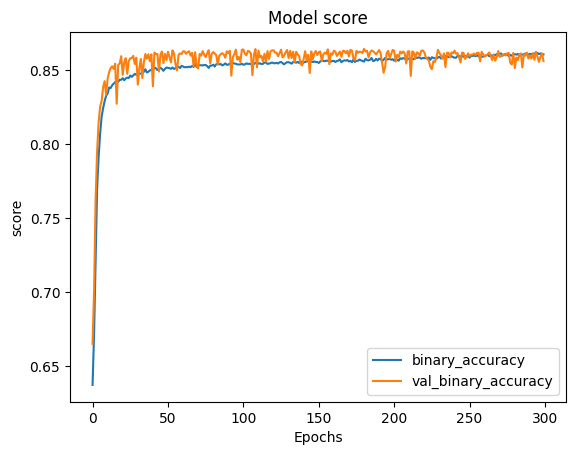

In [81]:
result[['binary_accuracy','val_binary_accuracy']].plot()
plt.title('Model score')
plt.xlabel('Epochs')
plt.ylabel('score')
plt.show()

In [82]:
from sklearn.metrics import confusion_matrix
ypred=model.predict(x_test)
ypred=(ypred>0.5)
cm=confusion_matrix(y_test,ypred)

812/812 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


In [83]:
print(cm)

[[12719  1854]
 [ 2250  9153]]


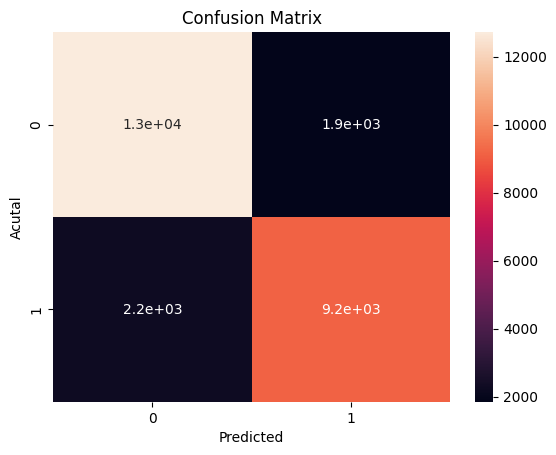

In [84]:
sns.heatmap(cm,annot=True)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Acutal')
plt.show()